# Bayesian Optimization Competition

This notebook implements a systematic approach to optimizing 8 black-box functions using Bayesian optimization with surrogate models.

## Competition Overview

- **Objective**: Maximize 8 black-box functions with different dimensionalities (2D to 8D)
- **Constraint**: 1 query per function per week
- **Approach**: Use surrogate models to predict function behavior and select optimal next queries

## Notebook Structure

1. **Setup and Data Loading** - Initialize environment and load function data
2. **Surrogate Model Framework** - Modular framework for different surrogate models
3. **Acquisition Functions** - Functions to select next query points
4. **Function Analysis Dashboard** - Visualize and analyze each function
5. **Weekly Query Generator** - Generate recommended queries for submission
6. **Update Models with Results** - Add new observations and retrain
7. **Progress Tracking** - Monitor optimization progress over time

# Section 1: Setup and Data Loading

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from abc import ABC, abstractmethod
from typing import Tuple, Dict, List, Optional
import warnings
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize

# Set random seed for reproducibility
np.random.seed(42)

# Configure warnings
warnings.filterwarnings('ignore')

# Configure matplotlib
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## FunctionData Class

In [2]:
class FunctionData:
    """Manages data for a single black-box function."""
    
    def __init__(self, function_id: int, data_dir: str = "../data"):
        self.function_id = function_id
        self.data_dir = Path(data_dir)
        self.function_dir = self.data_dir / f"function_{function_id}"
        
        # Load initial data
        self.inputs = np.load(self.function_dir / "initial_inputs.npy")
        self.outputs = np.load(self.function_dir / "initial_outputs.npy")
        
        # Store dimensions
        self.n_samples = len(self.outputs)
        self.n_dims = self.inputs.shape[1]
        
        # Track weekly updates
        self.week_number = 0
        self.history = []
        
    def add_observation(self, x: np.ndarray, y: float, week: Optional[int] = None):
        if week is None:
            self.week_number += 1
            week = self.week_number
        
        self.inputs = np.vstack([self.inputs, x.reshape(1, -1)])
        self.outputs = np.append(self.outputs, y)
        self.n_samples += 1
        self.history.append((week, x.copy(), y))
        
    def get_best(self) -> Tuple[np.ndarray, float]:
        best_idx = np.argmax(self.outputs)
        return self.inputs[best_idx], self.outputs[best_idx]
    
    def save_weekly_data(self, week: int):
        week_file_inputs = self.function_dir / f"week_{week}_inputs.npy"
        week_file_outputs = self.function_dir / f"week_{week}_outputs.npy"
        np.save(week_file_inputs, self.inputs)
        np.save(week_file_outputs, self.outputs)
        
    def get_summary(self) -> Dict:
        return {
            'function_id': self.function_id,
            'n_dims': self.n_dims,
            'n_samples': self.n_samples,
            'best_value': np.max(self.outputs),
            'mean_value': np.mean(self.outputs),
            'std_value': np.std(self.outputs)
        }
    
    def __repr__(self):
        best_x, best_y = self.get_best()
        return f"Function {self.function_id}: {self.n_dims}D, {self.n_samples} samples, best={best_y:.6f}"

print("✓ FunctionData class defined")

✓ FunctionData class defined


## Load All Functions

In [3]:
# Load all 8 functions
functions = {}
for i in range(1, 9):
    try:
        functions[i] = FunctionData(i)
        print(f"✓ Loaded {functions[i]}")
    except Exception as e:
        print(f"✗ Error loading function {i}: {e}")

print(f"\n✓ Successfully loaded {len(functions)} functions")

✓ Loaded Function 1: 2D, 10 samples, best=0.000000
✓ Loaded Function 2: 2D, 10 samples, best=0.611205
✓ Loaded Function 3: 3D, 15 samples, best=-0.034835
✓ Loaded Function 4: 4D, 30 samples, best=-4.025542
✓ Loaded Function 5: 4D, 20 samples, best=1088.859618
✓ Loaded Function 6: 5D, 20 samples, best=-0.714265
✓ Loaded Function 7: 6D, 30 samples, best=1.364968
✓ Loaded Function 8: 8D, 40 samples, best=9.598482

✓ Successfully loaded 8 functions


## Display Summary Statistics

In [4]:
print("=" * 80)
print(f"{'Func':<6} {'Dims':<6} {'Samples':<8} {'Best':<12} {'Mean':<12} {'Std':<12}")
print("=" * 80)

for func_id, func_data in functions.items():
    summary = func_data.get_summary()
    print(f"{func_id:<6} {summary['n_dims']:<6} {summary['n_samples']:<8} "
          f"{summary['best_value']:<12.6f} {summary['mean_value']:<12.6f} "
          f"{summary['std_value']:<12.6f}")

print("=" * 80)

Func   Dims   Samples  Best         Mean         Std         
1      2      10       0.000000     -0.000361    0.001082    
2      2      10       0.611205     0.230674     0.225365    
3      3      15       -0.034835    -0.107167    0.084214    
4      4      30       -4.025542    -17.238587   7.017985    
5      4      20       1088.859618  151.271876   245.575981  
6      5      20       -0.714265    -1.495390    0.449000    
7      6      30       1.364968     0.219607     0.302129    
8      8      40       9.598482     7.815274     0.946903    


# Section 2: Surrogate Model Framework

In [5]:
class SurrogateModel(ABC):
    """Abstract base class for surrogate models."""
    
    @abstractmethod
    def fit(self, X: np.ndarray, y: np.ndarray):
        pass
    
    @abstractmethod
    def predict(self, X: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        pass
    
    @abstractmethod
    def get_name(self) -> str:
        pass

print("✓ SurrogateModel base class defined")

✓ SurrogateModel base class defined


## Gaussian Process Surrogate

In [6]:
class GPSurrogate(SurrogateModel):
    """Gaussian Process surrogate model with RBF kernel."""
    
    def __init__(self, length_scale: float = 1.0, length_scale_bounds: Tuple = (1e-2, 1e2),
                 noise: float = 1e-5, optimize: bool = True):
        self.length_scale = length_scale
        self.length_scale_bounds = length_scale_bounds
        self.noise = noise
        self.optimize = optimize
        
        # Create kernel
        kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale, length_scale_bounds)
        
        # Create GP model
        self.model = GaussianProcessRegressor(
            kernel=kernel,
            alpha=noise,
            n_restarts_optimizer=10 if optimize else 0,
            normalize_y=True,
            random_state=42
        )
        
        self.is_fitted = False
        
    def fit(self, X: np.ndarray, y: np.ndarray):
        self.model.fit(X, y)
        self.is_fitted = True
        
    def predict(self, X: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        if not self.is_fitted:
            raise ValueError("Model must be fitted before prediction")
        mean, std = self.model.predict(X, return_std=True)
        return mean, std
    
    def get_name(self) -> str:
        return f"GP-RBF (ls={self.length_scale:.3f})"

print("✓ GPSurrogate class defined")

✓ GPSurrogate class defined


# Section 3: Acquisition Functions

In [7]:
class AcquisitionFunction:
    """Collection of acquisition functions for Bayesian optimization."""
    
    @staticmethod
    def ucb(mean: np.ndarray, std: np.ndarray, beta: float = 2.0) -> np.ndarray:
        """Upper Confidence Bound: UCB = mean + beta * std"""
        return mean + beta * std
    
    @staticmethod
    def ei(mean: np.ndarray, std: np.ndarray, y_best: float, xi: float = 0.01) -> np.ndarray:
        """Expected Improvement"""
        std = np.maximum(std, 1e-9)
        z = (mean - y_best - xi) / std
        ei_value = (mean - y_best - xi) * norm.cdf(z) + std * norm.pdf(z)
        return ei_value
    
    @staticmethod
    def pi(mean: np.ndarray, std: np.ndarray, y_best: float, xi: float = 0.01) -> np.ndarray:
        """Probability of Improvement"""
        std = np.maximum(std, 1e-9)
        z = (mean - y_best - xi) / std
        pi_value = norm.cdf(z)
        return pi_value

print("✓ Acquisition functions defined (UCB, EI, PI)")

✓ Acquisition functions defined (UCB, EI, PI)


## Optimize Acquisition Function

In [8]:
def optimize_acquisition(surrogate: SurrogateModel, func_data: FunctionData,
                         acq_func: str = 'ucb', n_random: int = 1000,
                         n_refine: int = 10, **acq_params) -> np.ndarray:
    """Find the point that maximizes the acquisition function."""
    n_dims = func_data.n_dims
    
    # Determine bounds from existing data
    bounds = []
    for i in range(n_dims):
        x_min, x_max = func_data.inputs[:, i].min(), func_data.inputs[:, i].max()
        margin = (x_max - x_min) * 0.1
        bounds.append((max(0, x_min - margin), min(1, x_max + margin)))
    
    # Stage 1: Random sampling
    X_random = np.random.uniform(0, 1, size=(n_random, n_dims))
    for i in range(n_dims):
        X_random[:, i] = X_random[:, i] * (bounds[i][1] - bounds[i][0]) + bounds[i][0]
    
    mean, std = surrogate.predict(X_random)
    
    # Calculate acquisition values
    if acq_func == 'ucb':
        acq_values = AcquisitionFunction.ucb(mean, std, beta=acq_params.get('beta', 2.0))
    elif acq_func == 'ei':
        _, y_best = func_data.get_best()
        acq_values = AcquisitionFunction.ei(mean, std, y_best, xi=acq_params.get('xi', 0.01))
    elif acq_func == 'pi':
        _, y_best = func_data.get_best()
        acq_values = AcquisitionFunction.pi(mean, std, y_best, xi=acq_params.get('xi', 0.01))
    else:
        raise ValueError(f"Unknown acquisition function: {acq_func}")
    
    # Stage 2: Local refinement
    best_candidates_idx = np.argsort(acq_values)[-n_refine:]
    best_candidate = None
    best_acq_value = -np.inf
    
    for idx in best_candidates_idx:
        x0 = X_random[idx]
        
        def objective(x):
            x = x.reshape(1, -1)
            mean, std = surrogate.predict(x)
            if acq_func == 'ucb':
                return -AcquisitionFunction.ucb(mean, std, beta=acq_params.get('beta', 2.0))[0]
            elif acq_func == 'ei':
                _, y_best = func_data.get_best()
                return -AcquisitionFunction.ei(mean, std, y_best, xi=acq_params.get('xi', 0.01))[0]
            else:
                _, y_best = func_data.get_best()
                return -AcquisitionFunction.pi(mean, std, y_best, xi=acq_params.get('xi', 0.01))[0]
        
        result = minimize(objective, x0, method='L-BFGS-B', bounds=bounds)
        
        if -result.fun > best_acq_value:
            best_acq_value = -result.fun
            best_candidate = result.x
    
    return best_candidate

print("✓ Acquisition optimization function defined")

✓ Acquisition optimization function defined


## Enhanced Acquisition Optimization (with Boundary Enforcement)

This improved version prevents queries from hitting extreme boundary values (0 or 1), which often lead to poor results, especially for high-dimensional functions like Function 8.

In [9]:
def optimize_acquisition_enhanced(surrogate: SurrogateModel, func_data: FunctionData,
                                   acq_func: str = 'ucb', n_random: int = 1000,
                                   n_refine: int = 10, 
                                   bound_margin: float = 0.02,  # Stay away from 0 and 1
                                   expand_search: bool = True,  # Search full [0,1] space
                                   **acq_params) -> Tuple[np.ndarray, float, float]:
    """
    Enhanced acquisition optimization with boundary enforcement.
    
    Args:
        surrogate: Fitted surrogate model
        func_data: Function data object
        acq_func: Acquisition function ('ucb', 'ei', 'pi')
        n_random: Number of random samples for global search
        n_refine: Number of local refinement starts
        bound_margin: Minimum distance from 0 and 1 (prevents boundary values)
        expand_search: If True, search full [0,1] space; if False, use data-driven bounds
        **acq_params: Additional parameters for acquisition function
    
    Returns:
        Tuple of (best_point, predicted_mean, predicted_std)
    """
    n_dims = func_data.n_dims
    
    # Scale n_random with dimensionality for better coverage
    n_random_scaled = n_random * (1 + n_dims // 4)  # More samples for higher dims
    
    # Determine bounds - enforce margin from edges
    if expand_search:
        # Search full space but avoid edges
        bounds = [(bound_margin, 1.0 - bound_margin) for _ in range(n_dims)]
    else:
        # Data-driven bounds with margin
        bounds = []
        for i in range(n_dims):
            x_min, x_max = func_data.inputs[:, i].min(), func_data.inputs[:, i].max()
            margin = (x_max - x_min) * 0.2  # 20% expansion
            lower = max(bound_margin, x_min - margin)
            upper = min(1.0 - bound_margin, x_max + margin)
            bounds.append((lower, upper))
    
    # Stage 1: Random sampling with stratified approach
    X_random = np.zeros((n_random_scaled, n_dims))
    for i in range(n_dims):
        X_random[:, i] = np.random.uniform(bounds[i][0], bounds[i][1], n_random_scaled)
    
    # Add some samples near the current best point (exploitation)
    best_x, _ = func_data.get_best()
    n_near_best = n_random_scaled // 5
    X_near_best = best_x + np.random.normal(0, 0.1, size=(n_near_best, n_dims))
    X_near_best = np.clip(X_near_best, bound_margin, 1.0 - bound_margin)
    X_random = np.vstack([X_random, X_near_best])
    
    mean, std = surrogate.predict(X_random)
    
    # Calculate acquisition values
    if acq_func == 'ucb':
        acq_values = AcquisitionFunction.ucb(mean, std, beta=acq_params.get('beta', 2.0))
    elif acq_func == 'ei':
        _, y_best = func_data.get_best()
        acq_values = AcquisitionFunction.ei(mean, std, y_best, xi=acq_params.get('xi', 0.01))
    elif acq_func == 'pi':
        _, y_best = func_data.get_best()
        acq_values = AcquisitionFunction.pi(mean, std, y_best, xi=acq_params.get('xi', 0.01))
    else:
        raise ValueError(f"Unknown acquisition function: {acq_func}")
    
    # Stage 2: Local refinement from top candidates
    best_candidates_idx = np.argsort(acq_values)[-n_refine:]
    # Initialize with best random candidate
    best_candidate = X_random[best_candidates_idx[-1]].copy()
    best_acq_value = -np.inf
    
    for idx in best_candidates_idx:
        x0 = X_random[idx]
        
        def objective(x):
            # Ensure x stays within bounds
            x = np.clip(x, bound_margin, 1.0 - bound_margin)
            x = x.reshape(1, -1)
            m, s = surrogate.predict(x)
            if acq_func == 'ucb':
                return -AcquisitionFunction.ucb(m, s, beta=acq_params.get('beta', 2.0))[0]
            elif acq_func == 'ei':
                _, y_best = func_data.get_best()
                return -AcquisitionFunction.ei(m, s, y_best, xi=acq_params.get('xi', 0.01))[0]
            else:
                _, y_best = func_data.get_best()
                return -AcquisitionFunction.pi(m, s, y_best, xi=acq_params.get('xi', 0.01))[0]
        
        result = minimize(objective, x0, method='L-BFGS-B', bounds=bounds)
        
        if -result.fun > best_acq_value:
            best_acq_value = -result.fun
            best_candidate = np.clip(result.x, bound_margin, 1.0 - bound_margin)
    
    # Get predictions at best candidate
    pred_mean, pred_std = surrogate.predict(best_candidate.reshape(1, -1))
    
    return best_candidate, pred_mean[0], pred_std[0]

print("✓ Enhanced acquisition optimization defined (with boundary enforcement)")

✓ Enhanced acquisition optimization defined (with boundary enforcement)


## 2D Function Surface Visualization

For Functions 1 and 2 (2D), visualize the GP prediction surface to understand where peaks might be located. This helps identify promising regions to explore.

In [10]:
def visualize_2d_surface(func_id: int, surrogate: Optional[SurrogateModel] = None, 
                         show_acquisition: bool = True, acq_func: str = 'ucb',
                         resolution: int = 50, **acq_params):
    """
    Visualize GP prediction surface for 2D functions.
    
    Args:
        func_id: Function ID (should be 1 or 2 for 2D functions)
        surrogate: Fitted surrogate model (creates new one if None)
        show_acquisition: Whether to also plot acquisition function
        acq_func: Acquisition function for visualization
        resolution: Grid resolution for surface
        **acq_params: Parameters for acquisition function
    """
    func_data = functions[func_id]
    
    if func_data.n_dims != 2:
        print(f"⚠ Function {func_id} is {func_data.n_dims}D, not 2D. Cannot visualize surface.")
        return
    
    # Create and fit surrogate if not provided
    if surrogate is None:
        surrogate = GPSurrogate(length_scale=0.5, optimize=True)
        surrogate.fit(func_data.inputs, func_data.outputs)
    
    # Create grid
    x0 = np.linspace(0.02, 0.98, resolution)  # Avoid boundaries
    x1 = np.linspace(0.02, 0.98, resolution)
    X0, X1 = np.meshgrid(x0, x1)
    X_grid = np.column_stack([X0.ravel(), X1.ravel()])
    
    # Predict
    mean, std = surrogate.predict(X_grid)
    mean_grid = mean.reshape(resolution, resolution)
    std_grid = std.reshape(resolution, resolution)
    
    # Calculate acquisition function and create plots
    if show_acquisition:
        # Calculate acquisition values
        if acq_func == 'ucb':
            acq_values = AcquisitionFunction.ucb(mean, std, beta=acq_params.get('beta', 2.0))
        elif acq_func == 'ei':
            _, y_best = func_data.get_best()
            acq_values = AcquisitionFunction.ei(mean, std, y_best, xi=acq_params.get('xi', 0.01))
        else:
            _, y_best = func_data.get_best()
            acq_values = AcquisitionFunction.pi(mean, std, y_best, xi=acq_params.get('xi', 0.01))
        acq_grid = acq_values.reshape(resolution, resolution)
        max_idx = np.argmax(acq_values)
        max_x = X_grid[max_idx]
    
    # Create figure
    n_cols = 3 if show_acquisition else 2
    fig, axes = plt.subplots(1, n_cols, figsize=(6*n_cols, 5))
    
    # Plot 1: Mean prediction
    ax1 = axes[0]
    c1 = ax1.contourf(X0, X1, mean_grid, levels=30, cmap='viridis')
    ax1.scatter(func_data.inputs[:, 0], func_data.inputs[:, 1], 
                c='red', s=100, edgecolors='white', linewidths=2, zorder=5,
                label='Observations')
    best_x, best_y = func_data.get_best()
    ax1.scatter(best_x[0], best_x[1], c='gold', s=200, marker='*', 
                edgecolors='black', linewidths=2, zorder=6, label=f'Best (y={best_y:.4f})')
    ax1.set_xlabel('x₀')
    ax1.set_ylabel('x₁')
    ax1.set_title(f'Function {func_id}: GP Mean Prediction')
    plt.colorbar(c1, ax=ax1, label='Predicted Value')
    ax1.legend(loc='upper right', fontsize=8)
    
    # Plot 2: Uncertainty (std)
    ax2 = axes[1]
    c2 = ax2.contourf(X0, X1, std_grid, levels=30, cmap='plasma')
    ax2.scatter(func_data.inputs[:, 0], func_data.inputs[:, 1], 
                c='white', s=80, edgecolors='black', linewidths=1, zorder=5)
    ax2.set_xlabel('x₀')
    ax2.set_ylabel('x₁')
    ax2.set_title(f'Function {func_id}: GP Uncertainty (σ)')
    plt.colorbar(c2, ax=ax2, label='Standard Deviation')
    
    # Plot 3: Acquisition function (if enabled)
    if show_acquisition:
        ax3 = axes[2]
        c3 = ax3.contourf(X0, X1, acq_grid, levels=30, cmap='RdYlGn')
        ax3.scatter(func_data.inputs[:, 0], func_data.inputs[:, 1], 
                    c='blue', s=80, edgecolors='white', linewidths=1, zorder=5)
        
        # Find and mark the maximum of acquisition function
        max_idx = np.argmax(acq_values)
        max_x = X_grid[max_idx]
        ax3.scatter(max_x[0], max_x[1], c='red', s=300, marker='*', 
                    edgecolors='black', linewidths=2, zorder=6, label='Next Query')
        
        ax3.set_xlabel('x₀')
        ax3.set_ylabel('x₁')
        ax3.set_title(f'Function {func_id}: {acq_func.upper()} Acquisition')
        plt.colorbar(c3, ax=ax3, label='Acquisition Value')
        ax3.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    # Print insights
    print(f"\n{'='*60}")
    print(f"Function {func_id} Surface Analysis")
    print(f"{'='*60}")
    print(f"Mean prediction range: [{mean.min():.4f}, {mean.max():.4f}]")
    print(f"Uncertainty range: [{std.min():.4f}, {std.max():.4f}]")
    print(f"Best observed: y = {best_y:.6f} at x = {best_x}")
    if show_acquisition:
        print(f"Suggested next query: {max_x}")
        pred_m, pred_s = surrogate.predict(max_x.reshape(1, -1))
        print(f"  Predicted: mean={pred_m[0]:.4f}, std={pred_s[0]:.4f}")
    print(f"{'='*60}")

print("✓ 2D surface visualization function defined")

✓ 2D surface visualization function defined


## Example: Visualize Function 1 and 2 Surfaces

Run these to understand where the GP thinks peaks might be located.

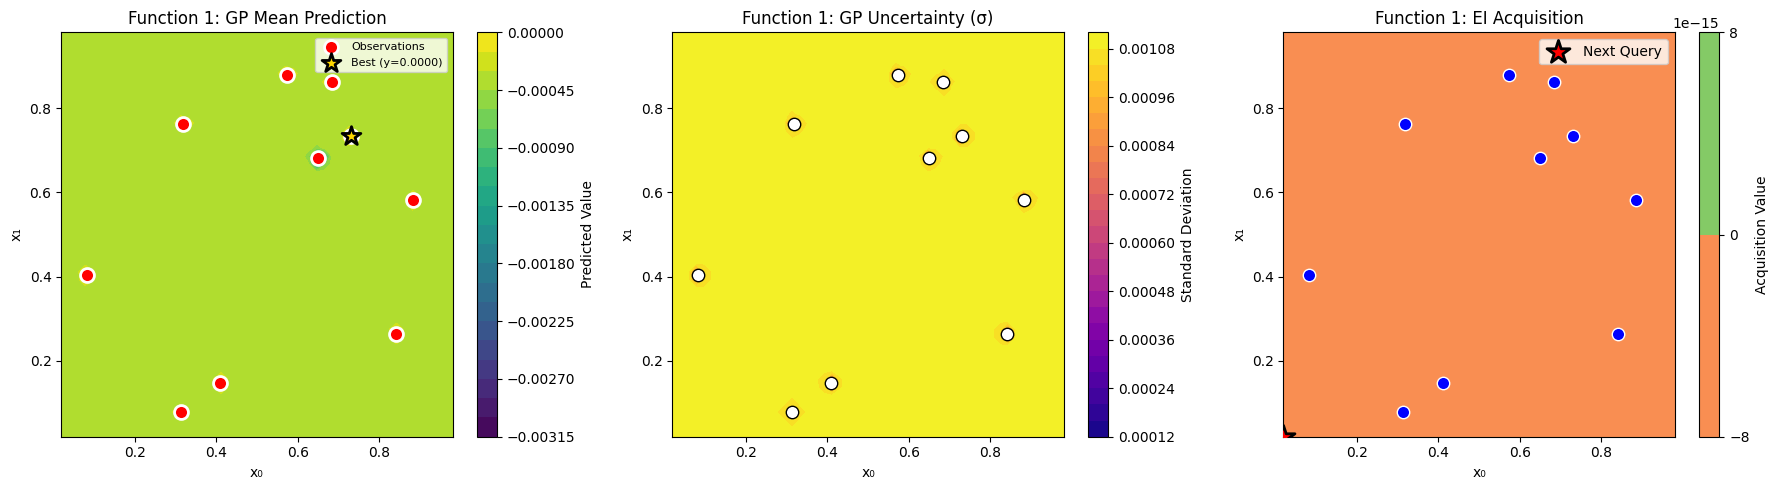


Function 1 Surface Analysis
Mean prediction range: [-0.0031, -0.0000]
Uncertainty range: [0.0001, 0.0011]
Best observed: y = 0.000000 at x = [0.73102363 0.73299988]
Suggested next query: [0.02 0.02]
  Predicted: mean=-0.0004, std=0.0011


In [11]:
# Visualize Function 1 (Contamination Detection)
# Uses EI with high exploration since Week 1 showed no improvement
visualize_2d_surface(1, acq_func='ei', xi=0.1)

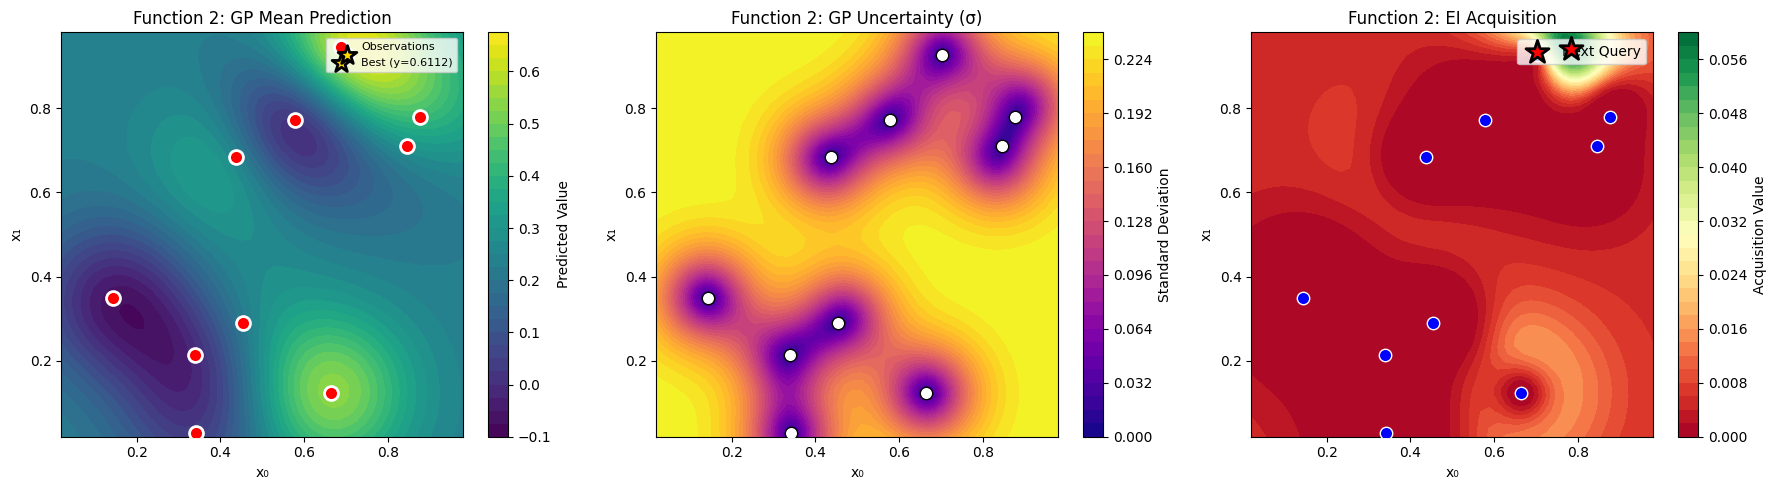


Function 2 Surface Analysis
Mean prediction range: [-0.0796, 0.6509]
Uncertainty range: [0.0046, 0.2389]
Best observed: y = 0.611205 at x = [0.70263656 0.9265642 ]
Suggested next query: [0.78408163 0.94081633]
  Predicted: mean=0.6369, std=0.1203


In [12]:
# Visualize Function 2 (Noisy ML Model)
# Uses EI with low exploration to exploit near known best region
visualize_2d_surface(2, acq_func='ei', xi=0.005)

## Prediction Tracking System

Track GP predictions vs actual results to understand model accuracy and improve strategy over time.

In [13]:
class PredictionTracker:
    """
    Track predictions vs actual results to analyze surrogate model accuracy.
    Helps identify when to adjust strategies.
    """
    
    def __init__(self):
        self.predictions = {}  # {week: {func_id: {'query': x, 'pred_mean': m, 'pred_std': s, 'actual': y}}}
        
    def record_prediction(self, week: int, func_id: int, query: np.ndarray, 
                         pred_mean: float, pred_std: float):
        """Record a prediction before submission."""
        if week not in self.predictions:
            self.predictions[week] = {}
        
        self.predictions[week][func_id] = {
            'query': query.copy(),
            'pred_mean': pred_mean,
            'pred_std': pred_std,
            'actual': None,
            'error': None,
            'within_2std': None
        }
    
    def update_actual(self, week: int, func_id: int, actual: float):
        """Update with actual result after receiving feedback."""
        if week in self.predictions and func_id in self.predictions[week]:
            pred = self.predictions[week][func_id]
            pred['actual'] = actual
            pred['error'] = actual - pred['pred_mean']
            # Check if actual was within 2 standard deviations of prediction
            pred['within_2std'] = abs(pred['error']) <= 2 * pred['pred_std']
    
    def update_all_actuals(self, week: int, outputs_dict: Dict[int, float]):
        """Update all functions with actual results."""
        for func_id, actual in outputs_dict.items():
            self.update_actual(week, func_id, actual)
    
    def analyze_accuracy(self, week: Optional[int] = None):
        """Analyze prediction accuracy for a specific week or all weeks."""
        print("=" * 80)
        print("PREDICTION ACCURACY ANALYSIS")
        print("=" * 80)
        
        weeks_to_analyze = [week] if week else sorted(self.predictions.keys())
        
        all_errors = []
        all_within_2std = []
        
        for w in weeks_to_analyze:
            if w not in self.predictions:
                continue
                
            print(f"\n📊 Week {w} Results:")
            print("-" * 60)
            print(f"{'Func':<6} {'Predicted':<12} {'Actual':<12} {'Error':<12} {'Within 2σ':<10}")
            print("-" * 60)
            
            for func_id in range(1, 9):
                if func_id not in self.predictions[w]:
                    continue
                    
                pred = self.predictions[w][func_id]
                if pred['actual'] is None:
                    print(f"{func_id:<6} {pred['pred_mean']:<12.4f} {'pending':<12} {'-':<12} {'-':<10}")
                else:
                    within = "✓" if pred['within_2std'] else "✗"
                    print(f"{func_id:<6} {pred['pred_mean']:<12.4f} {pred['actual']:<12.4f} "
                          f"{pred['error']:<12.4f} {within:<10}")
                    all_errors.append(pred['error'])
                    all_within_2std.append(pred['within_2std'])
        
        if all_errors:
            print("\n" + "=" * 60)
            print("OVERALL STATISTICS")
            print("=" * 60)
            errors = np.array(all_errors)
            print(f"Mean Absolute Error: {np.mean(np.abs(errors)):.4f}")
            print(f"Root Mean Squared Error: {np.sqrt(np.mean(errors**2)):.4f}")
            print(f"Predictions within 2σ: {sum(all_within_2std)}/{len(all_within_2std)} "
                  f"({100*sum(all_within_2std)/len(all_within_2std):.1f}%)")
            
            # Identify problematic functions
            print("\n⚠ Functions with largest prediction errors:")
            for w in weeks_to_analyze:
                if w not in self.predictions:
                    continue
                for func_id, pred in self.predictions[w].items():
                    if pred['actual'] is not None and abs(pred['error']) > 2 * pred['pred_std']:
                        print(f"  Function {func_id} (Week {w}): error={pred['error']:.4f}, "
                              f"2σ={2*pred['pred_std']:.4f}")
        
        print("=" * 80)
    
    def get_recommendations(self) -> Dict[int, str]:
        """Get strategy recommendations based on prediction accuracy."""
        recommendations = {}
        
        for func_id in range(1, 9):
            errors = []
            within_2std_count = 0
            total_count = 0
            
            for week_data in self.predictions.values():
                if func_id in week_data and week_data[func_id]['actual'] is not None:
                    errors.append(week_data[func_id]['error'])
                    if week_data[func_id]['within_2std']:
                        within_2std_count += 1
                    total_count += 1
            
            if not errors:
                recommendations[func_id] = "No data yet"
                continue
            
            avg_error = np.mean(errors)
            within_ratio = within_2std_count / total_count if total_count > 0 else 0
            
            if within_ratio < 0.5:
                recommendations[func_id] = "⚠ GP model unreliable - increase exploration (higher beta/xi)"
            elif avg_error < 0:
                recommendations[func_id] = "Model overestimates - consider more exploitation"
            elif avg_error > 0:
                recommendations[func_id] = "Model underestimates - potential for higher values exists"
            else:
                recommendations[func_id] = "Model accurate - current strategy is working"
        
        return recommendations

# Initialize global tracker
prediction_tracker = PredictionTracker()
print("✓ PredictionTracker class defined and tracker initialized")

✓ PredictionTracker class defined and tracker initialized


# Section 5.1: Week 2 Optimized Query Generation

Based on Week 1 analysis, we use customized strategies per function:
- **Problem functions (1, 2, 8)**: Changed strategies to address issues
- **Winning functions (3-7)**: Shift from exploration to exploitation

In [14]:
def generate_week2_queries(track_predictions: bool = True) -> Tuple[Dict[int, np.ndarray], Dict]:
    """
    Generate optimized queries for Week 2 based on Week 1 analysis.
    
    Strategy changes from Week 1:
    - Function 1: UCB β=2.5 → EI xi=0.1 (more exploration, function appears "dead")
    - Function 2: EI xi=0.01 → EI xi=0.005 (exploit near best region)
    - Function 3: UCB β=2.5 → UCB β=2.0 (found improvement, moderate exploitation)
    - Function 4: UCB β=2.0 → UCB β=1.5 (massive improvement, exploit region)
    - Function 5: UCB β=2.0 → EI xi=0.001 (massive improvement, heavy exploitation)
    - Function 6: UCB β=2.5 → UCB β=2.0 (steady improvement, balanced)
    - Function 7: UCB β=1.5 → UCB β=1.0 (good improvement, focus exploitation)
    - Function 8: UCB β=3.0 → EI xi=0.05 (switch to EI to avoid boundary-seeking)
    
    Args:
        track_predictions: Whether to record predictions in the tracker
    
    Returns:
        Dictionary of queries for each function
    """
    
    # Week 2 strategies based on Week 1 analysis
    week2_strategies = {
        # PROBLEM FUNCTIONS - need different approach
        1: {
            'acq_func': 'ei', 
            'xi': 0.1,  # High exploration for "dead" function
            'bound_margin': 0.02,
            'expand_search': True,  # Search full space
            'n_random': 2000,  # More samples
        },
        2: {
            'acq_func': 'ei', 
            'xi': 0.005,  # Lower exploration, exploit near best
            'bound_margin': 0.02,
            'expand_search': False,  # Focus on data-driven bounds
        },
        8: {
            'acq_func': 'ei',  # Changed from UCB to EI
            'xi': 0.05,  # Moderate exploration parameter
            'bound_margin': 0.10,  # Increased margin to be safe
            'expand_search': True,
            'n_random': 3000,  # Many more samples for 8D space
            'surrogate_params': {'length_scale': 0.3, 'optimize': True}
        },
        
        # WINNING FUNCTIONS - shift toward exploitation
        3: {'acq_func': 'ucb', 'beta': 2.0, 'bound_margin': 0.02},
        4: {'acq_func': 'ucb', 'beta': 1.5, 'bound_margin': 0.02},
        5: {'acq_func': 'ei', 'xi': 0.001, 'bound_margin': 0.02},  # Heavy exploitation
        6: {'acq_func': 'ucb', 'beta': 2.0, 'bound_margin': 0.02},
        7: {'acq_func': 'ucb', 'beta': 1.0, 'bound_margin': 0.02},  # Strong exploitation
    }
    
    queries = {}
    surrogates = {}
    
    print("=" * 80)
    print("GENERATING WEEK 2 QUERIES (Enhanced Strategy)")
    print("=" * 80)
    print("\nStrategy changes from Week 1:")
    print("  • Functions 1, 2, 8: Adjusted strategies to address issues")
    print("  • Functions 3-7: Shifted toward exploitation")
    print()
    
    for func_id in range(1, 9):
        func_data = functions[func_id]
        strategy = week2_strategies[func_id]
        
        # Extract surrogate params
        surrogate_params = strategy.get('surrogate_params', {'length_scale': 0.5, 'optimize': True})
        surrogate = GPSurrogate(**surrogate_params)
        surrogate.fit(func_data.inputs, func_data.outputs)
        
        # Extract acquisition params
        acq_func = strategy.get('acq_func', 'ucb')
        bound_margin = strategy.get('bound_margin', 0.02)
        expand_search = strategy.get('expand_search', True)
        n_random = strategy.get('n_random', 1000)
        
        acq_params = {k: v for k, v in strategy.items() 
                     if k not in ['acq_func', 'surrogate_params', 'bound_margin', 
                                  'expand_search', 'n_random']}
        
        # Use enhanced optimization with boundary enforcement
        next_query, pred_mean, pred_std = optimize_acquisition_enhanced(
            surrogate, func_data, 
            acq_func=acq_func,
            n_random=n_random,
            bound_margin=bound_margin,
            expand_search=expand_search,
            **acq_params
        )
        
        queries[func_id] = next_query
        surrogates[func_id] = surrogate
        
        # Track predictions if enabled
        if track_predictions:
            prediction_tracker.record_prediction(
                week=2, func_id=func_id, query=next_query,
                pred_mean=pred_mean, pred_std=pred_std
            )
        
        # Display results
        best_x, best_y = func_data.get_best()
        strategy_str = f"{acq_func.upper()}"
        if 'beta' in acq_params:
            strategy_str += f" β={acq_params['beta']}"
        if 'xi' in acq_params:
            strategy_str += f" ξ={acq_params['xi']}"
        
        # Indicate if this is a changed strategy
        status = "⚡ CHANGED" if func_id in [1, 2, 8] else "↓ exploit"
        
        print(f"Function {func_id} ({func_data.n_dims}D) [{status}] - {strategy_str}:")
        print(f"  Best so far: {best_y:.6f}")
        print(f"  Next query: {np.array2string(next_query, precision=6, separator=', ')}")
        print(f"  Predicted: mean={pred_mean:.6f}, std={pred_std:.6f}")
        print()
    
    print("=" * 80)
    print("✓ Week 2 queries generated with enhanced strategies")
    print("✓ Predictions recorded for accuracy tracking")
    print("=" * 80)
    
    return queries, surrogates

print("✓ Week 2 query generator defined")

✓ Week 2 query generator defined


## Generate Week 2 Queries

Run this cell to generate optimized Week 2 queries using the enhanced strategies.

In [15]:
# Generate Week 2 queries with enhanced strategies
week2_queries, week2_surrogates = generate_week2_queries(track_predictions=True)

GENERATING WEEK 2 QUERIES (Enhanced Strategy)

Strategy changes from Week 1:
  • Functions 1, 2, 8: Adjusted strategies to address issues
  • Functions 3-7: Shifted toward exploitation

Function 1 (2D) [⚡ CHANGED] - EI ξ=0.1:
  Best so far: 0.000000
  Next query: [0.69608 , 0.655743]
  Predicted: mean=-0.000361, std=0.001082

Function 2 (2D) [⚡ CHANGED] - EI ξ=0.005:
  Best so far: 0.611205
  Next query: [0.780352, 0.948276]
  Predicted: mean=0.637318, std=0.120363

Function 3 (3D) [↓ exploit] - UCB β=2.0:
  Best so far: -0.034835
  Next query: [0.42674 , 0.378188, 0.522189]
  Predicted: mean=-0.029781, std=0.075669

Function 4 (4D) [↓ exploit] - UCB β=1.5:
  Best so far: -4.025542
  Next query: [0.416785, 0.408733, 0.354862, 0.427478]
  Predicted: mean=-1.111108, std=0.570176

Function 5 (4D) [↓ exploit] - EI ξ=0.001:
  Best so far: 1088.859618
  Next query: [0.293631, 0.840346, 0.973392, 0.914577]
  Predicted: mean=1176.655110, std=77.437153

Function 6 (5D) [↓ exploit] - UCB β=2.0:


## Week 2 Portal Submission Format

Copy these values into the portal (uses HYPHENS as required).

In [16]:
# Format Week 2 queries for portal submission
format_for_portal(week2_queries)

NameError: name 'format_for_portal' is not defined

## Analyze Predictions (Run after receiving Week 2 results)

After you receive Week 2 results, run this to update the tracker and analyze prediction accuracy.

In [ ]:
# After receiving Week 2 results, update the tracker:
# prediction_tracker.update_all_actuals(week=2, outputs_dict=outputs_week2)

# Then analyze accuracy:
# prediction_tracker.analyze_accuracy(week=2)

# Get recommendations for Week 3:
# recommendations = prediction_tracker.get_recommendations()
# for func_id, rec in recommendations.items():
#     print(f"Function {func_id}: {rec}")

print("Template ready - uncomment and run after receiving Week 2 results")

# Section 4: Function Analysis

Analyze individual functions with visualization (for 2D functions).

In [ ]:
def analyze_function(func_id: int, surrogate: SurrogateModel = None, 
                     acq_func: str = 'ucb', **acq_params):
    """Complete analysis of a single function."""
    func_data = functions[func_id]
    
    # Create and fit surrogate if not provided
    if surrogate is None:
        surrogate = GPSurrogate(length_scale=0.5, optimize=True)
    
    surrogate.fit(func_data.inputs, func_data.outputs)
    
    # Find next query point
    next_query = optimize_acquisition(surrogate, func_data, acq_func=acq_func, **acq_params)
    
    # Display summary
    best_x, best_y = func_data.get_best()
    print("=" * 80)
    print(f"FUNCTION {func_id} ANALYSIS")
    print("=" * 80)
    print(f"Dimensions: {func_data.n_dims}D")
    print(f"Samples: {func_data.n_samples}")
    print(f"Best observed value: {best_y:.6f}")
    print(f"Best input: {np.array2string(best_x, precision=4, separator=', ')}")
    print(f"\\nSurrogate model: {surrogate.get_name()}")
    print(f"Acquisition function: {acq_func.upper()}")
    print(f"\\nSuggested next query:")
    print(f"  x = {np.array2string(next_query, precision=6, separator=', ')}")
    
    # Predict at next query
    mean, std = surrogate.predict(next_query.reshape(1, -1))
    print(f"  Predicted: mean={mean[0]:.6f}, std={std[0]:.6f}")
    print("=" * 80)
    print()
    
    # Visualize for 2D functions
    if func_data.n_dims == 2:
        # Simple visualization for 2D
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.scatter(func_data.inputs[:, 0], func_data.inputs[:, 1], 
                  c=func_data.outputs, s=100, cmap='viridis', edgecolors='white', linewidths=2)
        ax.scatter(next_query[0], next_query[1], c='red', s=300, marker='*', 
                  edgecolors='white', linewidths=2, label='Next Query')
        ax.set_xlabel('x₀')
        ax.set_ylabel('x₁')
        ax.set_title(f'Function {func_id}: Current Observations and Next Query')
        ax.legend()
        plt.colorbar(ax.collections[0], ax=ax, label='Function Value')
        plt.show()
    else:
        print(f"(2D visualization skipped for {func_data.n_dims}D function)")
    
    return next_query, surrogate

print("✓ Analysis function defined")

✓ Analysis function defined


In [ ]:
## Example: Analyze a Specific Function

#Change the function_id to analyze different functions (1-8).

# Analyze function 1 (2D function with visualization)
next_query, surrogate_model = analyze_function(6, acq_func='ucb', beta=2.5)

# Section 5: Weekly Query Generator

Generate query points for all 8 functions at once for weekly submission.

In [ ]:
def generate_weekly_queries(acq_func: str = 'ucb', surrogate_params: Dict = None,
                           **acq_params) -> Dict[int, np.ndarray]:
    """Generate query points for all functions."""
    if surrogate_params is None:
        surrogate_params = {'length_scale': 0.5, 'optimize': True}
    
    queries = {}
    surrogates = {}
    
    print("=" * 80)
    print("GENERATING WEEKLY QUERIES FOR ALL FUNCTIONS")
    print("=" * 80)
    print(f"Acquisition function: {acq_func.upper()}")
    print(f"Acquisition params: {acq_params}")
    print("=" * 80)
    print()
    
    for func_id in range(1, 9):
        func_data = functions[func_id]
        
        # Create and fit surrogate
        surrogate = GPSurrogate(**surrogate_params)
        surrogate.fit(func_data.inputs, func_data.outputs)
        
        # Find next query
        next_query = optimize_acquisition(surrogate, func_data, acq_func=acq_func, **acq_params)
        
        queries[func_id] = next_query
        surrogates[func_id] = surrogate
        
        # Display
        best_x, best_y = func_data.get_best()
        mean, std = surrogate.predict(next_query.reshape(1, -1))
        
        print(f"Function {func_id} ({func_data.n_dims}D):")
        print(f"  Best so far: {best_y:.6f}")
        print(f"  Next query: {np.array2string(next_query, precision=6, separator=', ')}")
        print(f"  Predicted: mean={mean[0]:.6f}, std={std[0]:.6f}")
        print()
    
    print("=" * 80)
    return queries, surrogates

print("✓ Weekly query generator defined")

✓ Weekly query generator defined


## Generate Queries for This Week

## Advanced: Custom Strategy Per Function

This function allows you to specify different strategies for each function.

In [ ]:
def generate_custom_queries(strategies: Dict[int, Dict] = None):
    """
    Generate queries with custom strategies per function.
    
    Args:
        strategies: Dict mapping function_id to strategy params
                   Example: {1: {'acq_func': 'ucb', 'beta': 2.0},
                            2: {'acq_func': 'ei', 'xi': 0.1}}
    
    If strategies is None, uses recommended defaults based on function characteristics.
    """
    # Default recommended strategies if none provided
    if strategies is None:
        strategies = {
            1: {'acq_func': 'ucb', 'beta': 2.5},  # 2D contamination - explore peaks
            2: {'acq_func': 'ei', 'xi': 0.01},    # Noisy - use EI
            3: {'acq_func': 'ucb', 'beta': 2.5},  # 3D drug - balanced
            4: {'acq_func': 'ucb', 'beta': 2.0},  # Dynamic - sustained exploration
            5: {'acq_func': 'ucb', 'beta': 2.0},  # Unimodal - can exploit more
            6: {'acq_func': 'ucb', 'beta': 2.5},  # 5D recipe - balanced
            7: {'acq_func': 'ucb', 'beta': 1.5},  # ML hyperparam - moderate
            8: {'acq_func': 'ucb', 'beta': 3.0},  # 8D - high exploration
        }
    
    queries = {}
    surrogates = {}
    
    print("=" * 80)
    print("GENERATING CUSTOM WEEKLY QUERIES")
    print("=" * 80)
    print()
    
    for func_id in range(1, 9):
        func_data = functions[func_id]
        strategy = strategies.get(func_id, {'acq_func': 'ucb', 'beta': 2.0})
        
        # Create and fit surrogate
        surrogate_params = strategy.get('surrogate_params', {'length_scale': 0.5, 'optimize': True})
        surrogate = GPSurrogate(**surrogate_params)
        surrogate.fit(func_data.inputs, func_data.outputs)
        
        # Extract acquisition params
        acq_func = strategy.get('acq_func', 'ucb')
        acq_params = {k: v for k, v in strategy.items() 
                     if k not in ['acq_func', 'surrogate_params']}
        
        # Find next query
        next_query = optimize_acquisition(surrogate, func_data, 
                                         acq_func=acq_func, **acq_params)
        
        queries[func_id] = next_query
        surrogates[func_id] = surrogate
        
        # Display
        best_x, best_y = func_data.get_best()
        mean, std = surrogate.predict(next_query.reshape(1, -1))
        
        print(f"Function {func_id} ({func_data.n_dims}D) - {acq_func.upper()} {acq_params}:")
        print(f"  Best so far: {best_y:.6f}")
        print(f"  Next query: {np.array2string(next_query, precision=6, separator=', ')}")
        print(f"  Predicted: mean={mean[0]:.6f}, std={std[0]:.6f}")
        print()
    
    print("=" * 80)
    return queries, surrogates

print("✓ Custom strategy query generator defined")

✓ Custom strategy query generator defined


## Option 1: Use Simple Generator (Same Strategy for All)

In [ ]:
/# Simple approach: Same strategy for all functions
# weekly_queries, _ = generate_weekly_queries(acq_func='ucb', beta=2.0)

print("Uncomment above to use simple approach")

## Option 2: Use Custom Strategies (RECOMMENDED)

In [ ]:
# Option A: Use recommended defaults (tuned for each function)
# weekly_queries, weekly_surrogates = generate_custom_queries()

# Option B: Customize for specific functions
my_strategies = {
     1: {'acq_func': 'ei', 'xi': 0.1},      # More exploration for function 1
     2: {'acq_func': 'ei', 'xi': 0.005},         # EI for noisy function 2
     3: {'acq_func': 'UCB', 'beta': 2.0}, 
     4: {'acq_func': 'UCB', 'beta': 1.5},
     5: {'acq_func': 'UCB', 'beta': 1.2},
     6: {'acq_func': 'UCB', 'beta': 2.0},
     7: {'acq_func': 'UCB', 'beta': 1.0},
     8: {'acq_func': 'ucb', 'beta': 2.5,         # Less extreme exploration
        'surrogate_params': {'length_scale': 0.3, 'optimize': True}},                # Aggressive exploitation for unimodal
     # Functions not specified use {'acq_func': 'ucb', 'beta': 2.0}
 }
weekly_queries, weekly_surrogates = generate_custom_queries(my_strategies)

GENERATING CUSTOM WEEKLY QUERIES

Function 1 (2D) - UCB {'beta': 2.5}:
  Best so far: 0.000000
  Next query: [0.390475, 0.150055]
  Predicted: mean=-0.000313, std=0.001072

Function 2 (2D) - EI {'xi': 0.01}:
  Best so far: 0.611205
  Next query: [0.781541, 0.948752]
  Predicted: mean=0.636168, std=0.121992

Function 3 (3D) - UCB {'beta': 2.5}:
  Best so far: -0.034835
  Next query: [0.442633, 0.362694, 0.536069]
  Predicted: mean=-0.036940, std=0.078864

Function 4 (4D) - UCB {'beta': 2.0}:
  Best so far: -4.025542
  Next query: [0.413055, 0.408176, 0.347266, 0.431309]
  Predicted: mean=-1.140825, std=0.587126

Function 5 (4D) - UCB {'beta': 2.0}:
  Best so far: 1088.859618
  Next query: [0.378897, 0.842367, 0.958538, 0.999568]
  Predicted: mean=1092.128595, std=149.491453

Function 6 (5D) - UCB {'beta': 2.5}:
  Best so far: -0.714265
  Next query: [0.248237, 0.314846, 0.411998, 0.758207, 0.      ]
  Predicted: mean=-0.664995, std=0.368419

Function 7 (6D) - UCB {'beta': 1.5}:
  Best s

## IMPORTANT: Portal Submission Format

**The portal expects HYPHENS, not commas!**  
Format: `x1-x2-x3-...-xn`

In [ ]:
def format_for_portal(queries: Dict[int, np.ndarray]):
    """
    Format queries correctly for the competition portal.
    Portal expects: x1-x2-x3-...-xn (HYPHENS not commas!)
    """
    print("=" * 80)
    print("PORTAL SUBMISSION FORMAT")
    print("=" * 80)
    print()
    
    for func_id in range(1, 9):
        if func_id in queries:
            query = queries[func_id]
            # Portal format uses HYPHENS between values
            query_str = "-".join([f"{x:.6f}" for x in query])
            print(f"Function {func_id}: {query_str}")
        else:
            print(f"Function {func_id}: -")
    
    print()
    print("=" * 80)
    print("Copy the values above and paste into the portal")
    print("=" * 80)

# Format with correct portal format (hyphens!)
format_for_portal(weekly_queries)

PORTAL SUBMISSION FORMAT

Function 1: 0.390475-0.150055
Function 2: 0.781541-0.948752
Function 3: 0.442633-0.362694-0.536069
Function 4: 0.413055-0.408176-0.347266-0.431309
Function 5: 0.378897-0.842367-0.958538-0.999568
Function 6: 0.248237-0.314846-0.411998-0.758207-0.000000
Function 7: 0.026972-0.427861-0.300063-0.167708-0.357189-0.730491
Function 8: 0.138513-0.000000-0.000000-0.000000-1.000000-0.000000-0.000000-0.000000

Copy the values above and paste into the portal


In [ ]:
# Generate queries using UCB acquisition function
weekly_queries, weekly_surrogates = generate_weekly_queries(acq_func='ucb', beta=2.0)

## Format Queries for Submission

In [ ]:
def format_queries_for_submission(queries: Dict[int, np.ndarray]):
    """Format queries in a submission-ready format."""
    print("=" * 80)
    print("WEEKLY SUBMISSION - QUERY POINTS")
    print("=" * 80)
    print()
    
    for func_id, query in queries.items():
        print(f"Function {func_id}:")
        query_str = ", ".join([f"{x:.6f}" for x in query])
        print(f"  {query_str}")
        print()
    
    print("=" * 80)

# Format the generated queries
format_queries_for_submission(weekly_queries)

# Section 6: Update Models with New Results

When you receive results from weekly submissions, use these cells to update your models.

## Two Approaches Available:

1. **Automated Loading** (Recommended): Load results from Week directories (e.g., `Week 1/inputs.txt` and `Week 1/outputs.txt`)
2. **Manual Updates**: Manually specify individual function updates when needed

Both approaches are supported below.

## Approach 1: Automated Loading from Week Directories

In [18]:
import ast
import re

def load_weekly_results(week_num: int, base_dir: str = "..") -> tuple:
    """
    Load inputs and outputs from a Week directory.
    
    Args:
        week_num: Week number (e.g., 1 for "Week 1")
        base_dir: Base directory containing Week folders (default: "..")
    
    Returns:
        tuple: (inputs_dict, outputs_dict) where keys are function IDs (1-8)
               and values are numpy arrays
    
    Expected file format:
        - inputs.txt: Python list of numpy arrays [array([...]), array([...]), ...]
        - outputs.txt: Python list of values [value1, value2, ...]
    """
    base_path = Path(base_dir)
    week_dir = base_path / f"Week {week_num}"
    
    # Check if directory exists
    if not week_dir.exists():
        raise FileNotFoundError(f"Week directory not found: {week_dir}")
    
    inputs_file = week_dir / "inputs.txt"
    outputs_file = week_dir / "outputs.txt"
    
    # Check if files exist
    if not inputs_file.exists():
        raise FileNotFoundError(f"Inputs file not found: {inputs_file}")
    if not outputs_file.exists():
        raise FileNotFoundError(f"Outputs file not found: {outputs_file}")
    
    try:
        # Read and parse inputs
        with open(inputs_file, 'r') as f:
            inputs_content = f.read().strip()
        
        # Preprocess: Remove 'array(' calls to make it parseable by ast.literal_eval
        # Replace 'array(' with '(' so we get plain tuples/lists
        inputs_content_clean = re.sub(r'array\(', '(', inputs_content)
        inputs_list = ast.literal_eval(inputs_content_clean)
        
        # Read and parse outputs
        with open(outputs_file, 'r') as f:
            outputs_content = f.read().strip()
        
        # Clean outputs: remove np.float64() wrappers if present
        outputs_content_clean = re.sub(r'np\.float64\(', '(', outputs_content)
        outputs_list = ast.literal_eval(outputs_content_clean)
        
        # Verify we have exactly 8 functions
        if len(inputs_list) != 8:
            raise ValueError(f"Expected 8 input arrays, got {len(inputs_list)}")
        if len(outputs_list) != 8:
            raise ValueError(f"Expected 8 output values, got {len(outputs_list)}")
        
        # Convert to dictionaries with function IDs as keys
        inputs_dict = {}
        outputs_dict = {}
        
        for func_id in range(1, 9):
            idx = func_id - 1  # Convert to 0-based index
            
            # Convert input to numpy array if it isn't already
            if isinstance(inputs_list[idx], np.ndarray):
                inputs_dict[func_id] = inputs_list[idx]
            else:
                inputs_dict[func_id] = np.array(inputs_list[idx])
            
            # Extract output value (handle np.float64 wrapper)
            output_val = outputs_list[idx]
            if hasattr(output_val, 'item'):  # np.float64 or similar
                outputs_dict[func_id] = float(output_val)
            else:
                outputs_dict[func_id] = float(output_val)
        
        print(f"✓ Successfully loaded Week {week_num} results")
        print(f"  Location: {week_dir}")
        print(f"  Functions: 1-8")
        
        return inputs_dict, outputs_dict
        
    except SyntaxError as e:
        raise ValueError(f"Failed to parse results files. Check file format. Error: {e}")
    except Exception as e:
        raise RuntimeError(f"Error loading weekly results: {e}")

print("✓ load_weekly_results() function defined")

✓ load_weekly_results() function defined


In [25]:
def update_all_functions_with_results(inputs_dict: dict, outputs_dict: dict, 
                                      week: int, save: bool = True):
    """
    Update all functions with weekly results.
    
    Args:
        inputs_dict: Dictionary mapping function IDs (1-8) to input arrays
        outputs_dict: Dictionary mapping function IDs (1-8) to output values
        week: Week number for tracking
        save: Whether to save updated data to disk
    """
    print("=" * 80)
    print(f"UPDATING ALL FUNCTIONS WITH WEEK {week} RESULTS")
    print("=" * 80)
    print()
    
    # Store results for summary
    results = []
    
    for func_id in range(1, 9):
        if func_id not in inputs_dict or func_id not in outputs_dict:
            print(f"⚠ Warning: Function {func_id} missing from results. Skipping.")
            continue
        
        x = inputs_dict[func_id]
        y = outputs_dict[func_id]
        
        # Get function data
        func_data = functions[func_id]
        
        # Store old best for comparison
        old_best_x, old_best_y = func_data.get_best()
        
        # Add observation
        func_data.add_observation(x, y, week)
        
        # Save if requested
        if save:
            func_data.save_weekly_data(week)
        
        # Get new best
        new_best_x, new_best_y = func_data.get_best()
        
        # Check if this is a new best
        is_new_best = new_best_y > old_best_y
        improvement = new_best_y - old_best_y if is_new_best else 0
        
        # Store for summary
        results.append({
            'func_id': func_id,
            'n_dims': func_data.n_dims,
            'y': y,
            'best_y': new_best_y,
            'is_new_best': is_new_best,
            'improvement': improvement,
            'n_samples': func_data.n_samples
        })
        
        # Print individual update
        status = "🌟 NEW BEST!" if is_new_best else "✓"
        print(f"{status} Function {func_id} ({func_data.n_dims}D):")
        print(f"    New observation: y = {y:.6f}")
        print(f"    Best so far: {new_best_y:.6f}")
        if is_new_best:
            print(f"    Improvement: +{improvement:.6f}")
        print(f"    Total samples: {func_data.n_samples}")
        print()
    
    # Print summary table
    print("=" * 80)
    print("SUMMARY")
    print("=" * 80)
    print(f"{'Func':<6} {'Dims':<6} {'New Y':<12} {'Best Y':<12} {'Status':<15} {'Samples':<8}")
    print("-" * 80)
    
    for r in results:
        status = f"+{r['improvement']:.4f}" if r['is_new_best'] else "no change"
        print(f"{r['func_id']:<6} {r['n_dims']:<6} {r['y']:<12.6f} {r['best_y']:<12.6f} "
              f"{status:<15} {r['n_samples']:<8}")
    
    print("=" * 80)
    
    new_bests = sum(1 for r in results if r['is_new_best'])
    print(f"\n✓ Updated {len(results)} functions")
    print(f"🌟 Found {new_bests} new best values")
    
    return results

print("✓ update_all_functions_with_results() function defined")

✓ update_all_functions_with_results() function defined


## Load and Process Week 2 Results

Use this cell to automatically load and process Week 2 results.

In [26]:
# Load Week 1 results
inputs_week1, outputs_week1 = load_weekly_results(week_num=1)

# Update all functions with Week 1 results
week1_results = update_all_functions_with_results(inputs_week1, outputs_week1, week=1, save=True)

ValueError: Failed to parse results files. Check file format. Error: unmatched ']' (<unknown>, line 1)

In [29]:
# Load Week 2 results
inputs_week2, outputs_week2 = load_weekly_results(week_num=2)

ValueError: Failed to parse results files. Check file format. Error: unmatched ']' (<unknown>, line 1)

In [30]:
# BETTER FIX - handles multi-line arrays properly
def load_weekly_results(week_num: int, base_dir: str = "..") -> tuple:
    """
    Load inputs and outputs from a Week directory.
    Handles files with multiple submissions by finding complete list structures.
    """
    base_path = Path(base_dir)
    week_dir = base_path / f"Week {week_num}"
    
    if not week_dir.exists():
        raise FileNotFoundError(f"Week directory not found: {week_dir}")
    
    inputs_file = week_dir / "inputs.txt"
    outputs_file = week_dir / "outputs.txt"
    
    if not inputs_file.exists():
        raise FileNotFoundError(f"Inputs file not found: {inputs_file}")
    if not outputs_file.exists():
        raise FileNotFoundError(f"Outputs file not found: {outputs_file}")
    
    try:
        # Read entire file content
        with open(inputs_file, 'r') as f:
            full_content = f.read()
        
        # Split by lines and find complete list structures (starting with '[')
        # Filter for lines that start a new list
        list_starts = []
        current_list = []
        for line in full_content.split('\n'):
            if line.strip().startswith('['):
                if current_list:  # Save previous list
                    list_starts.append('\n'.join(current_list))
                current_list = [line]
            elif current_list:  # Continue building current list
                current_list.append(line)
        # Don't forget the last one
        if current_list:
            list_starts.append('\n'.join(current_list))
        
        # Take the last complete list (most recent week)
        inputs_content = list_starts[-1]
        
        # Preprocess: Remove 'array(' calls
        inputs_content_clean = re.sub(r'array\(', '(', inputs_content)
        inputs_list = ast.literal_eval(inputs_content_clean)
        
        # Same for outputs
        with open(outputs_file, 'r') as f:
            full_content = f.read()
        
        list_starts = []
        current_list = []
        for line in full_content.split('\n'):
            if line.strip().startswith('['):
                if current_list:
                    list_starts.append('\n'.join(current_list))
                current_list = [line]
            elif current_list:
                current_list.append(line)
        if current_list:
            list_starts.append('\n'.join(current_list))
        
        outputs_content = list_starts[-1]
        
        # Clean outputs: remove np.float64() wrappers
        outputs_content_clean = re.sub(r'np\.float64\(', '(', outputs_content)
        outputs_list = ast.literal_eval(outputs_content_clean)
        
        # Verify we have exactly 8 functions
        if len(inputs_list) != 8:
            raise ValueError(f"Expected 8 input arrays, got {len(inputs_list)}")
        if len(outputs_list) != 8:
            raise ValueError(f"Expected 8 output values, got {len(outputs_list)}")
        
        # Convert to dictionaries
        inputs_dict = {}
        outputs_dict = {}
        
        for func_id in range(1, 9):
            idx = func_id - 1
            
            if isinstance(inputs_list[idx], np.ndarray):
                inputs_dict[func_id] = inputs_list[idx]
            else:
                inputs_dict[func_id] = np.array(inputs_list[idx])
            
            output_val = outputs_list[idx]
            if hasattr(output_val, 'item'):
                outputs_dict[func_id] = float(output_val)
            else:
                outputs_dict[func_id] = float(output_val)
        
        print(f"✓ Successfully loaded Week {week_num} results")
        print(f"  Location: {week_dir}")
        print(f"  Functions: 1-8")
        
        return inputs_dict, outputs_dict
        
    except SyntaxError as e:
        raise ValueError(f"Failed to parse results files. Check file format. Error: {e}")
    except Exception as e:
        raise RuntimeError(f"Error loading weekly results: {e}")

print("✓ BETTER FIXED load_weekly_results() function defined")

✓ BETTER FIXED load_weekly_results() function defined


In [31]:
week2_results = update_all_functions_with_results(inputs_week2, outputs_week2, week=2, save=True)

NameError: name 'inputs_week2' is not defined

## For Future Weeks

To load and process results from future weeks, use the same pattern:

```python
# Week 2
inputs_week2, outputs_week2 = load_weekly_results(week_num=2)
week2_results = update_all_functions_with_results(inputs_week2, outputs_week2, week=2, save=True)

# Week 3
inputs_week3, outputs_week3 = load_weekly_results(week_num=3)
week3_results = update_all_functions_with_results(inputs_week3, outputs_week3, week=3, save=True)

# And so on...
```

**Expected Directory Structure:**
```
Week 1/
  ├── inputs.txt
  └── outputs.txt
Week 2/
  ├── inputs.txt
  └── outputs.txt
...
```

**File Format:**
- `inputs.txt`: List of 8 numpy arrays (one per function)
- `outputs.txt`: List of 8 float values (corresponding outputs)

## Approach 2: Manual Updates

Use this approach when you need to update individual functions or when you have results in a different format.

In [ ]:
def update_function_with_result(func_id: int, x: np.ndarray, y: float, 
                                week: Optional[int] = None, save: bool = True):
    """
    Update a single function with a new observation.
    
    Args:
        func_id: Function ID (1-8)
        x: Input point that was queried
        y: Observed output value
        week: Week number (auto-increments if None)
        save: Whether to save updated data to disk
    """
    func_data = functions[func_id]
    func_data.add_observation(x, y, week)
    
    if save and week is not None:
        func_data.save_weekly_data(week)
    
    best_x, best_y = func_data.get_best()
    print(f"✓ Function {func_id} updated:")
    print(f"  New observation: y = {y:.6f}")
    print(f"  Best so far: {best_y:.6f}")
    print(f"  Total samples: {func_data.n_samples}")

print("✓ update_function_with_result() function defined")

### Manual Update Examples

Uncomment and modify these lines when you receive results and want to update functions individually.

In [ ]:
# Example 1: Update a single function with a manually specified result
# x_new = np.array([0.5, 0.3])  # The input you submitted
# y_new = 1.234  # The result you received
# update_function_with_result(func_id=1, x=x_new, y=y_new, week=1, save=True)

# Example 2: Update using previously generated queries
# If you generated queries using weekly_queries (from Section 5), you can use them directly:
# x_new = weekly_queries[1]  # Query for function 1
# y_new = 1.234  # The result you received
# update_function_with_result(func_id=1, x=x_new, y=y_new, week=1, save=True)

# Example 3: Update all functions manually (if not using automated loading)
# for func_id in range(1, 9):
#     x_new = weekly_queries[func_id]  # Or specify manually
#     y_new = ...  # Replace with actual result
#     update_function_with_result(func_id, x_new, y_new, week=1, save=True)

print("Manual update template ready - uncomment and modify when needed")

In [ ]:
# Note: update_function_with_result() is defined in Cell 42 above
# This duplicate definition has been removed to avoid redefinition warnings

## Example: Update Functions with Results

Uncomment and modify these lines when you receive results.

In [ ]:
# Example: Update function 1 with result from week 1
# x_new = weekly_queries[1]  # The query you submitted
# y_new = 0.123456  # The result you received
# update_function_with_result(1, x_new, y_new, week=1, save=True)

# Update all functions at once:
# for func_id in range(1, 9):
#     x_new = weekly_queries[func_id]
#     y_new = ... # Replace with actual result
#     update_function_with_result(func_id, x_new, y_new, week=1, save=True)

print("Update template ready - modify and uncomment when results arrive")

# Section 7: Progress Tracking

Monitor optimization progress over time.

In [ ]:
def plot_progress(func_ids: List[int] = None):
    """Plot optimization progress for selected functions."""
    if func_ids is None:
        func_ids = list(range(1, 9))
    
    n_funcs = len(func_ids)
    n_cols = min(3, n_funcs)
    n_rows = (n_funcs + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
    if n_funcs == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_funcs > 1 else [axes]
    
    for idx, func_id in enumerate(func_ids):
        func_data = functions[func_id]
        ax = axes[idx]
        
        # Plot cumulative best
        cumulative_best = np.maximum.accumulate(func_data.outputs)
        samples = np.arange(1, len(cumulative_best) + 1)
        
        ax.plot(samples, cumulative_best, 'b-', linewidth=2, label='Best Value')
        ax.scatter(samples, func_data.outputs, c='lightblue', 
                  alpha=0.5, s=30, label='Observations')
        
        # Highlight weekly updates if any
        if func_data.history:
            history_values = [h[2] for h in func_data.history]
            history_indices = list(range(len(func_data.outputs) - len(history_values), 
                                       len(func_data.outputs)))
            ax.scatter(np.array(history_indices) + 1, history_values, 
                      c='red', s=100, marker='*', 
                      label='Weekly Updates', zorder=5)
        
        ax.set_xlabel('Sample Number')
        ax.set_ylabel('Function Value')
        ax.set_title(f'Function {func_id} ({func_data.n_dims}D)')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(n_funcs, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

print("✓ Progress plotting function defined")

## View Progress for All Functions

In [ ]:
# Plot progress for all functions
plot_progress()

## Summary Statistics

In [ ]:
def display_competition_summary():
    """Display overall competition progress."""
    print("=" * 80)
    print("COMPETITION SUMMARY")
    print("=" * 80)
    print()
    
    total_queries = sum(f.week_number for f in functions.values())
    
    print(f"Total weekly submissions: {max(f.week_number for f in functions.values())}")
    print(f"Total queries made: {total_queries}")
    print()
    print("Best values by function:")
    print("-" * 80)
    
    for func_id in range(1, 9):
        func_data = functions[func_id]
        best_x, best_y = func_data.get_best()
        improvement = best_y - func_data.outputs[0] if len(func_data.outputs) > 0 else 0
        
        print(f"Function {func_id} ({func_data.n_dims}D): {best_y:.6f} "
              f"(+{improvement:.6f} improvement, {func_data.n_samples} samples)")
    
    print("=" * 80)

display_competition_summary()

## Format Queries for Submission

Display queries in a format ready for copy-paste submission.

In [ ]:
def format_queries_for_submission(queries: Dict[int, np.ndarray]):
    """Format queries in a submission-ready format."""
    print("=" * 80)
    print("WEEKLY SUBMISSION - QUERY POINTS")
    print("=" * 80)
    print()
    
    for func_id, query in queries.items():
        print(f"Function {func_id}:")
        # Format as comma-separated values for easy copy-paste
        query_str = ", ".join([f"{x:.6f}" for x in query])
        print(f"  {query_str}")
        print()
    
    print("=" * 80)

# Format the generated queries
format_queries_for_submission(weekly_queries)

# Section 6: Update Models with New Results

Add new observations when you receive results from the weekly submission.

In [ ]:
# Note: update_function_with_result() is defined in Cell 42 above
# This duplicate definition has been removed to avoid redefinition warnings

## Example: Update Function with New Result

When you receive results, update each function using this template.

In [ ]:
# Example: Update function 1 with result from week 1
# Replace with actual query point and result
# x_new = weekly_queries[1]  # The query you submitted
# y_new = 0.123456  # The result you received
# update_function_with_result(1, x_new, y_new, week=1, save=True)

print("Example code ready - uncomment and fill in actual values when results arrive")

# Section 7: Progress Tracking

Track optimization progress over time.

In [ ]:
def plot_progress(func_ids: List[int] = None):
    """
    Plot optimization progress for selected functions.
    
    Args:
        func_ids: List of function IDs to plot (None = all)
    """
    if func_ids is None:
        func_ids = list(range(1, 9))
    
    n_funcs = len(func_ids)
    n_cols = min(3, n_funcs)
    n_rows = (n_funcs + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
    if n_funcs == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_funcs > 1 else [axes]
    
    for idx, func_id in enumerate(func_ids):
        func_data = functions[func_id]
        ax = axes[idx]
        
        # Plot cumulative best
        cumulative_best = np.maximum.accumulate(func_data.outputs)
        samples = np.arange(1, len(cumulative_best) + 1)
        
        ax.plot(samples, cumulative_best, 'b-', linewidth=2, label='Best Value')
        ax.scatter(samples, func_data.outputs, c='lightblue', 
                  alpha=0.5, s=30, label='Observations')
        
        # Highlight new observations from history
        if func_data.history:
            history_values = [h[2] for h in func_data.history]
            history_indices = list(range(len(func_data.outputs) - len(history_values), 
                                       len(func_data.outputs)))
            ax.scatter(np.array(history_indices) + 1, history_values, 
                      c='red', s=100, marker='*', 
                      edgecolors='darkred', linewidths=1,
                      label='Weekly Updates', zorder=5)
        
        ax.set_xlabel('Sample Number')
        ax.set_ylabel('Function Value')
        ax.set_title(f'Function {func_id} ({func_data.n_dims}D) - Progress')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(n_funcs, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

print("✓ Progress plotting function defined")

## View Progress for All Functions

In [ ]:
# Plot progress for all functions
plot_progress()

## Summary Statistics Across All Functions

In [ ]:
def display_competition_summary():
    """Display overall competition progress."""
    print("=" * 80)
    print("COMPETITION SUMMARY")
    print("=" * 80)
    print()
    
    total_queries = sum(f.week_number for f in functions.values())
    
    print(f"Total weekly submissions: {max(f.week_number for f in functions.values())}")
    print(f"Total queries made: {total_queries}")
    print()
    print("Best values by function:")
    print("-" * 80)
    
    for func_id in range(1, 9):
        func_data = functions[func_id]
        best_x, best_y = func_data.get_best()
        improvement = best_y - func_data.outputs[0] if len(func_data.outputs) > 0 else 0
        
        print(f"Function {func_id} ({func_data.n_dims}D): {best_y:.6f} "
              f"(+{improvement:.6f} improvement, {func_data.n_samples} samples)")
    
    print("=" * 80)

display_competition_summary()